# 0. Imports

In [1]:
#!pip install -qq ipython numpy pandas scikit-learn statsmodels xgboost torch

In [2]:
import sys
import warnings
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd

import sklearn
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

import statsmodels.api as sm
from statsmodels.tools.sm_exceptions import ConvergenceWarning

import xgboost
from xgboost import XGBRegressor

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# --- New from Edward ---

#from sklearn.ensemble import RandomForestRegressor
#from matplotlib import pyplot as plt

#from sklearn.cluster import AgglomerativeClustering
#import numpy as np
#from scipy.cluster.hierarchy import dendrogram
#from sklearn import cluster

import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

# --- New from Edward ---

In [3]:
!python --version
print("numpy", np.__version__)
print("pandas", pd.__version__)
print("scikit-learn", sklearn.__version__)
print("torch", torch.__version__)
print("feat_boost", "custom")

Python 3.10.18
numpy 2.0.1
pandas 2.3.2
scikit-learn 1.7.1
torch 2.6.0
feat_boost custom


In [4]:
# Extract all datasets from /data/ into a nested dictionary.
DFDICT = {
    subdir.name: {
        csv.stem: pd.read_csv(csv, dtype="string", low_memory=False)
        for csv in subdir.glob("*.csv")
    }
    for subdir in (Path.cwd() / "data").iterdir() if subdir.is_dir()
}

# 1. Preprocessing

### 1.1 Select and Join Datasets

In [5]:
# Here we select what data to use from what's available.

# Specify a set of columns from each dataset for selection
weatherCols = [
    "DATE",
    "HourlyDryBulbTemperature",
    "HourlyRelativeHumidity",
    "HourlyWindSpeed",
    "HourlyStationPressure",
    "HourlyVisibility"
]
electricityCols = [
    "UTC time",
    "Hour",
    "Demand",
]

# Select all 2024 weather and electrical data from those columns
DFW = DFDICT['weather']['MIA_2024'][weatherCols]
DFE = DFDICT['electricity']['FPL'][electricityCols]
DFE = DFE.iloc[ (i := 24 * (8*365 + 2 + 31*4 + 30*2)) : i + 24*366].copy()

In [6]:
# Eletrical grid observations are ALWAYS every hour on the hour.  
# Weather observations are temporally much messier.
# The output below shows the distribution of temporal differences 
#  across all 2024 weather observations.

_df = pd.DataFrame({"t": pd.to_datetime(DFW["DATE"])})
_df["delta t"] = (
    _df["t"].diff()
    .apply(lambda x: "" if pd.isna(x) else str(x).split()[-1])
)

print("Number of rows: ", len(_df), end='\n\n')
print(_df.head(10), end="\n\n")
with pd.option_context("display.max_rows", None):
    print(_df["delta t"].value_counts().sort_index().reset_index(name="Count"))

Number of rows:  13105

                    t   delta t
0 2024-01-01 00:53:00          
1 2024-01-01 01:00:00  00:07:00
2 2024-01-01 01:53:00  00:53:00
3 2024-01-01 02:53:00  01:00:00
4 2024-01-01 03:53:00  01:00:00
5 2024-01-01 04:00:00  00:07:00
6 2024-01-01 04:53:00  00:53:00
7 2024-01-01 05:53:00  01:00:00
8 2024-01-01 06:53:00  01:00:00
9 2024-01-01 07:00:00  00:07:00

     delta t  Count
0                 1
1   00:00:00     17
2   00:01:00     16
3   00:02:00    186
4   00:03:00     72
5   00:04:00     48
6   00:05:00     61
7   00:06:00    393
8   00:07:00   2820
9   00:08:00     40
10  00:09:00     42
11  00:10:00     52
12  00:11:00     54
13  00:12:00     41
14  00:13:00     45
15  00:14:00     42
16  00:15:00     38
17  00:16:00     36
18  00:17:00     50
19  00:18:00     35
20  00:19:00     35
21  00:20:00     36
22  00:21:00     45
23  00:22:00     38
24  00:23:00     33
25  00:24:00     25
26  00:25:00     28
27  00:26:00     35
28  00:27:00     30
29  00:28:00     27
30 

In [7]:
# Each dataset's time columns is replace by with another in local time
#  which is UTC-5 (the weather data needs no time adjustment).
_dfe, _dfw = (
    DFE.drop(columns=["UTC time"])
       .assign(t=pd.to_datetime(DFE["UTC time"]) - pd.Timedelta(hours=5)),
    DFW.drop(columns=["DATE"])
       .assign(t=pd.to_datetime(DFW["DATE"]))
)

# Merge both dataframes, joining records on their time measurement.
# CRITICALLY, the nearest weather obversation to each hour is naively taken.
# THIS IS BAD AND NEEDS TO BE CHANGED.
DF = pd.merge_asof(_dfe, _dfw, on="t", direction="nearest")
display(DF)

,Hour,Demand,t,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyWindSpeed,HourlyStationPressure,HourlyVisibility
0,24,"11,815",2024-01-01 00:00:00,57,81,5,30.20,7.00
1,1,"11,254",2024-01-01 01:00:00,57,81,5,30.20,6.84
2,2,"11,109",2024-01-01 02:00:00,57,81,0,30.19,6.00
3,3,"10,861",2024-01-01 03:00:00,56,87,0,30.18,6.00
4,4,"10,736",2024-01-01 04:00:00,55,87,3,30.17,9.94
...,...,...,...,...,...,...,...,...
8779,19,"16,796",2024-12-31 19:00:00,75,84,0,29.94,9.94
8780,20,"15,515",2024-12-31 20:00:00,74,88,3,<NA>,10.00
8781,21,"14,348",2024-12-31 21:00:00,74,88,0,<NA>,10.00
8782,22,"13,391",2024-12-31 22:00:00,73,90,5,29.98,9.94


In [8]:
# # Count missing values, list unique weather data values.

# print(DF.shape)
# print()

# for c in [*electricityCols[1:], *weatherCols[1:]]:
#     print(f"{c:<25} {(DF[c].isna()).sum()}")
# print()

# for c in weatherCols[1:]:
#     print(f"{c}: Unique Values")
#     print(DF[c].unique().tolist())
#     print()

### 1.2 Convert Datatypes and Construct Features

In [9]:
# Convert to numeric dtypes and impute missing values.
# CRITICALLY, the nearest observation is imputed for each missing value again.
# THIS IS BAD AND NEEDS TO BE CHANGED.

DF["HourlyDryBulbTemperature"] = DF["HourlyDryBulbTemperature"].str[:2]
for c in weatherCols[1:]:
    converted = pd.to_numeric(DF[c], errors="coerce") 
    intFlag = (converted.dropna() % 1 == 0).all()
    imputed = converted.interpolate(method="nearest").ffill().bfill()
    DF[c] = imputed.astype("uint8" if intFlag else "float32")

converted = pd.to_numeric(DF["Demand"].str.replace(",", "", regex=False), errors="coerce")
DF["Demand"] = converted.interpolate(method="nearest").fillna(0).astype("uint16")
DF["Hour"] = pd.to_numeric(DF["Hour"]).astype("uint8")

display(DF)

,Hour,Demand,t,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyWindSpeed,HourlyStationPressure,HourlyVisibility
0,24,11815,2024-01-01 00:00:00,57,81,5,30.200001,7.00
1,1,11254,2024-01-01 01:00:00,57,81,5,30.200001,6.84
2,2,11109,2024-01-01 02:00:00,57,81,0,30.190001,6.00
3,3,10861,2024-01-01 03:00:00,56,87,0,30.180000,6.00
4,4,10736,2024-01-01 04:00:00,55,87,3,30.170000,9.94
...,...,...,...,...,...,...,...,...
8779,19,16796,2024-12-31 19:00:00,75,84,0,29.940001,9.94
8780,20,15515,2024-12-31 20:00:00,74,88,3,29.940001,10.00
8781,21,14348,2024-12-31 21:00:00,74,88,0,29.980000,10.00
8782,22,13391,2024-12-31 22:00:00,73,90,5,29.980000,9.94


In [10]:
# Make sure the column name is *exactly* this:
col = "HourlyStationPressure"

s = pd.to_numeric(DF[col], errors="coerce")
print("Before: NaNs in HourlyStationPressure =", s.isna().sum())

s = s.interpolate(method="nearest").ffill().bfill()
print("After interpolate+ffill+bfill: NaNs =", s.isna().sum())

DF[col] = s.astype("float32")
print("In DF: NaNs in HourlyStationPressure =", DF[col].isna().sum())

Before: NaNs in HourlyStationPressure = 1
After interpolate+ffill+bfill: NaNs = 0
In DF: NaNs in HourlyStationPressure = 0


In [11]:
# Construct additional features from the selected columns

# AUTOREGRESSIVE FEATURES
# In this case each include each of the previous 3 hrs of measured demand
#  along with the previous day and week (24 and 168 hrs).
# ! The first h rows are blank for these features - here we backfill them. CHANGE
# ! Many more should be included, especially for the DL models.
lag_hours = [1, 2, 3, 24, 168]
for h in lag_hours:
    DF[f"lag_{h}"] = DF["Demand"].shift(h).bfill().astype("float32")
lagFeats = [f"lag_{h}" for h in lag_hours]

# CALENDAR FEATURES
# For now, just trig transformations on the hour of day and a one-hot encoding for weekends.
# ! Flags can be included for each day of the week, each month, holidays, etc.
DF["sin(h)"] = np.sin(2 * np.pi * DF["Hour"] / 24.0).astype("float32")
DF["cos(h)"] = np.cos(2 * np.pi * DF["Hour"] / 24.0).astype("float32")
DF["is_weekend"] = (DF["t"].dt.dayofweek >= 5).astype("int8")
DF = DF.drop(columns=["Hour"])
calendarFeats = ["sin(h)", "cos(h)", "is_weekend"]

# WEATHER FEATURES
# We don't extract any new features yet for this category.
weatherFeats = weatherCols[1:]  # skip DATE

# Define other convenient feature variables.
allFeats = lagFeats + calendarFeats + weatherFeats
target = "Demand"

# Drop rows missing any needed inputs (initial lags, any NAs)
DFmodel = DF.sort_values("t").reset_index(drop=True)
print("Model DF shape:", DFmodel.shape)

nan_count = DFmodel.isna().sum()
print(nan_count)

Model DF shape: (8784, 15)
Demand                      0
t                           0
HourlyDryBulbTemperature    0
HourlyRelativeHumidity      0
HourlyWindSpeed             0
HourlyStationPressure       0
HourlyVisibility            0
lag_1                       0
lag_2                       0
lag_3                       0
lag_24                      0
lag_168                     0
sin(h)                      0
cos(h)                      0
is_weekend                  0
dtype: int64


### 1.3 Data Splits

In [12]:
# Split out last 5 weeks of data for testing.

nTestDays = 35
testStartTime = DFmodel["t"].max() - pd.Timedelta(days=nTestDays)

DFtrain = DFmodel[DFmodel["t"] <  testStartTime].copy()
DFtest  = DFmodel[DFmodel["t"] >= testStartTime].copy()

X_train = DFtrain[allFeats].to_numpy(dtype=np.float32)
y_train = DFtrain[target].to_numpy(dtype=np.float32)
X_test  = DFtest[allFeats].to_numpy(dtype=np.float32)
y_test  = DFtest[target].to_numpy(dtype=np.float32)

print("Train size:  ", len(DFtrain))
print("Test size:   ", len(DFtest))
print("Train range: ", DFtrain["t"].min(), " - ", DFtrain["t"].max())
print("Test range:  ", DFtest["t"].min(),  " - ", DFtest["t"].max())

Train size:   7943
Test size:    841
Train range:  2024-01-01 00:00:00  -  2024-11-26 22:00:00
Test range:   2024-11-26 23:00:00  -  2024-12-31 23:00:00


Feature importance scores:
 [9.44536480e-01 2.10355023e-03 3.64743739e-03 1.75613655e-02
 1.34471960e-03 3.57857689e-03 2.21613106e-02 1.75666385e-04
 3.32271839e-03 5.52977594e-04 3.94437204e-04 5.28446214e-04
 9.23135555e-05]


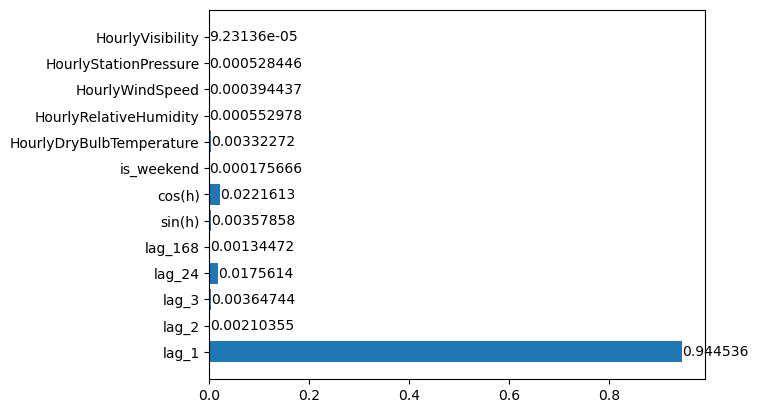

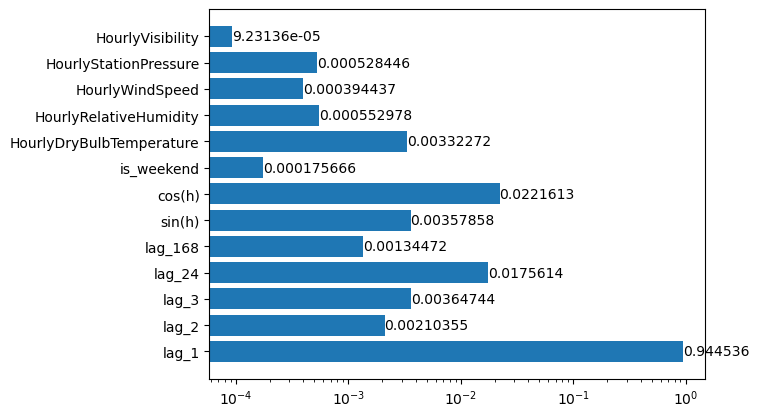

In [13]:
# --- New from Edward ---

# Load feature selection raw data
X_fs = DFtrain[allFeats]
y_fs = DFtrain[target]


# Fit random forest model
fs_model = RandomForestRegressor(n_estimators=50, random_state=42)
fs_model.fit(X_fs, y_fs)


# Show feature importance scores
print("Feature importance scores:\n", fs_model.feature_importances_)


# Plot feature importance scores
fs_plot_names = allFeats
fs_plot_ticks = fs_plot_names

fig, ax = plt.subplots()
bars = ax.barh(fs_plot_ticks, fs_model.feature_importances_)
ax.bar_label(bars)
ax.set_yticks(fs_plot_ticks, fs_plot_names)
ax.set_xscale('linear')
plt.show()

fig, ax = plt.subplots()
bars = ax.barh(fs_plot_ticks, fs_model.feature_importances_)
ax.bar_label(bars)
ax.set_yticks(fs_plot_ticks, fs_plot_names)
ax.set_xscale('log')
plt.show()

# --- New from Edward ---

In [14]:
### 1.5 Feature Selection using Scikit Learn

In [15]:
'''
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)



XX_fs = DFtrain[allFeats].to_numpy(dtype=np.float32)
print(XX_fs.shape)

fsfs_model = AgglomerativeClustering(compute_distances=True, n_clusters=4)
fsfs_model.fit(XX_fs)

print(fsfs_model.labels_)

plt.title("Hierarchical Clustering Dendrogram")
plot_dendrogram(fsfs_model, truncate_mode="level", p=13)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

fsfs_agglo = cluster.FeatureAgglomeration(n_clusters=13)
fsfs_agglo.fit(XX_fs)
XX_reduced = fsfs_agglo.transform(XX_fs)
print(XX_reduced.shape)
'''

'\ndef plot_dendrogram(model, **kwargs):\n    # Create linkage matrix and then plot the dendrogram\n\n    # create the counts of samples under each node\n    counts = np.zeros(model.children_.shape[0])\n    n_samples = len(model.labels_)\n    for i, merge in enumerate(model.children_):\n        current_count = 0\n        for child_idx in merge:\n            if child_idx < n_samples:\n                current_count += 1  # leaf node\n            else:\n                current_count += counts[child_idx - n_samples]\n        counts[i] = current_count\n\n    linkage_matrix = np.column_stack(\n        [model.children_, model.distances_, counts]\n    ).astype(float)\n\n    # Plot the corresponding dendrogram\n    dendrogram(linkage_matrix, **kwargs)\n\n\n\nXX_fs = DFtrain[allFeats].to_numpy(dtype=np.float32)\nprint(XX_fs.shape)\n\nfsfs_model = AgglomerativeClustering(compute_distances=True, n_clusters=4)\nfsfs_model.fit(XX_fs)\n\nprint(fsfs_model.labels_)\n\nplt.title("Hierarchical Clustering

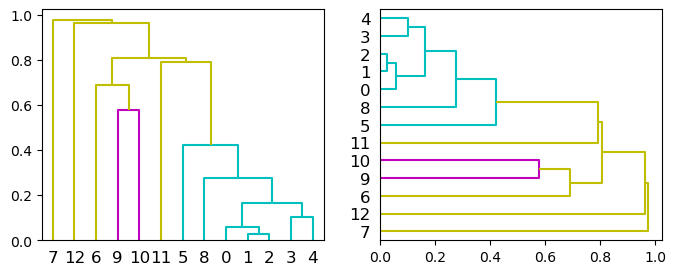

In [16]:
### 1.6 Feature Selection using SciPi

# SciPy's cluster.hierarchy.linkage or SKLearn's cluster.AgglomerativeClustering can be used 
# to cluster a set of features based on "distance" (in our case 1 - corr). 
# You can visualize this with SciPy's cluster.hierarchy.dendrogram and then use SciPy's cluster.hierarchy.fcluster 
# to "cut" the dendrogram at a certain similarity threshold or into a desired number of clusters.

# you can then plot that DF_clusters object with dendrogram() and use fclusters() to get clusters of correlated columns



DF_X = DFtrain[allFeats]
DF_y = DFtrain[target]

fs_corr = DF_X.corr(method="spearman")
fs_distance = 1.0 - fs_corr.abs()

DF_clusters = linkage(squareform(fs_distance.values, checks=False), method="average")

#fs_dendrogram = dendrogram(DF_clusters)



hierarchy.set_link_color_palette(['m', 'c', 'y', 'k'])
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
dn1 = dendrogram(DF_clusters, ax=axes[0], above_threshold_color='y', orientation='top')
dn2 = dendrogram(DF_clusters, ax=axes[1], above_threshold_color='y', orientation='right')
hierarchy.set_link_color_palette(None)  # reset to default after use
plt.show()



